In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [2]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

# Fix embeddings
df["hour"] = df["hour"].astype(int) % 24
df["day_of_week"] = df["day_of_week"].astype(int) % 7
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

# Remove leakage
if "sum_zones" in df.columns:
    df = df.drop(columns=["sum_zones"])

In [3]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

target_cols = zone_cols + ["load"]

In [4]:
SEQ_LEN = 24

class MultiModalDataset(Dataset):
    def __init__(self, df):
        self.load_data = df[load_features].values.astype(np.float32)
        self.temp_data = df[temp_features].values.astype(np.float32)
        self.cal_data = df[calendar_features].values.astype(np.int64)
        self.targets = df[target_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.load_data) - SEQ_LEN

    def __getitem__(self, idx):
        Xl = self.load_data[idx:idx+SEQ_LEN]
        Xt = self.temp_data[idx:idx+SEQ_LEN]
        Xc = self.cal_data[idx:idx+SEQ_LEN]
        y = self.targets[idx+SEQ_LEN]

        return (
            torch.tensor(Xl),
            torch.tensor(Xt),
            torch.tensor(Xc),
            torch.tensor(y)
        )

split_idx = int(0.8 * len(df))

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

scaler = MinMaxScaler()

scale_cols = (
    load_features +
    temp_features +
    target_cols
)

train_df[scale_cols] = scaler.fit_transform(
    train_df[scale_cols]
)

test_df[scale_cols] = scaler.transform(
    test_df[scale_cols]
)

train_ds = MultiModalDataset(train_df)
test_ds = MultiModalDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

In [5]:
class QuantileModel(nn.Module):
    def __init__(self, num_targets, quantiles):
        super().__init__()
        self.quantiles = quantiles

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        fusion_size = 64 + 32 + 18

        self.fc = nn.Sequential(
            nn.Linear(fusion_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_targets * len(quantiles))
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        hour = self.hour_emb(Xc[:, -1, 0])
        day = self.day_emb(Xc[:, -1, 1])
        month = self.month_emb(Xc[:, -1, 2])
        weekend = self.weekend_emb(Xc[:, -1, 3])

        cal_out = torch.cat([hour, day, month, weekend], dim=1)

        fused = torch.cat([load_out, temp_out, cal_out], dim=1)

        out = self.fc(fused)

        return out.view(out.size(0), len(target_cols), len(self.quantiles))

In [6]:
def quantile_loss(preds, target, quantiles):
    loss = 0
    for i, q in enumerate(quantiles):
        errors = target - preds[:, :, i]
        loss += torch.mean(torch.max((q - 1) * errors, q * errors))
    return loss

In [7]:
quantiles = [0.1, 0.5, 0.9]

model = QuantileModel(len(target_cols), quantiles).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xl, Xt, Xc, y in train_loader:
        Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(Xl, Xt, Xc)

        loss = quantile_loss(preds, y, quantiles)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 61.3355
Epoch 2 | Loss: 30.7471
Epoch 3 | Loss: 27.1499
Epoch 4 | Loss: 24.8015
Epoch 5 | Loss: 22.6084
Epoch 6 | Loss: 21.4636
Epoch 7 | Loss: 20.4174
Epoch 8 | Loss: 19.2782
Epoch 9 | Loss: 19.0304
Epoch 10 | Loss: 18.3032
Epoch 11 | Loss: 18.2844
Epoch 12 | Loss: 18.0074
Epoch 13 | Loss: 17.4299
Epoch 14 | Loss: 17.3669
Epoch 15 | Loss: 17.0136
Epoch 16 | Loss: 16.7565
Epoch 17 | Loss: 16.6320
Epoch 18 | Loss: 16.3399
Epoch 19 | Loss: 16.2888
Epoch 20 | Loss: 16.4507


In [8]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for Xl, Xt, Xc, y in test_loader:
        Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

        preds = model(Xl, Xt, Xc).cpu().numpy()

        all_preds.append(preds)
        all_true.append(y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

In [9]:
p10 = all_preds[:, -1, 0]
p50 = all_preds[:, -1, 1]
p90 = all_preds[:, -1, 2]

actual = all_true[:, -1]

In [10]:
threshold = np.percentile(all_true[:, -1], 95)

peak_mask = actual >= threshold

print("Peak threshold:", threshold)
print("Number of peak points:", peak_mask.sum())

Peak threshold: 0.64742893
Number of peak points: 786


In [11]:
actual_peak = actual[peak_mask]
p50_peak = p50[peak_mask]
p90_peak = p90[peak_mask]

# MAE
mae_p50 = np.mean(np.abs(actual_peak - p50_peak))
mae_p90 = np.mean(np.abs(actual_peak - p90_peak))

# Bias
bias_p50 = np.mean(p50_peak - actual_peak)
bias_p90 = np.mean(p90_peak - actual_peak)

# Peak capture
capture_rate = np.mean(actual_peak <= p90_peak)

results = pd.DataFrame({
    "Metric": ["MAE_P50", "MAE_P90", "Bias_P50", "Bias_P90", "Peak Capture Rate"],
    "Value": [mae_p50, mae_p90, bias_p50, bias_p90, capture_rate]
})

results.to_csv("outputs/tables/rq4_peak_results.csv", index=False)

results

,Metric,Value
0,MAE_P50,0.015283
1,MAE_P90,0.039168
2,Bias_P50,-0.002873
3,Bias_P90,0.038769
4,Peak Capture Rate,0.975827


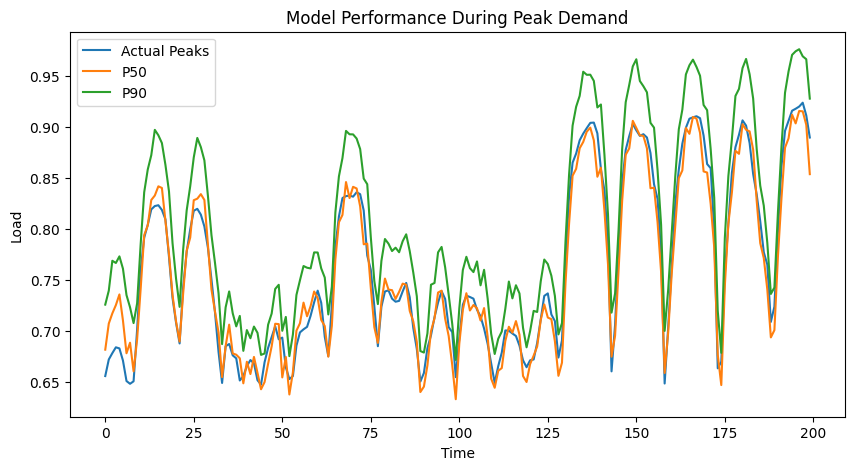

In [12]:
plt.figure(figsize=(10,5))

plt.plot(actual_peak[:200], label="Actual Peaks")
plt.plot(p50_peak[:200], label="P50")
plt.plot(p90_peak[:200], label="P90")

plt.legend()
plt.title("Model Performance During Peak Demand")
plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig("outputs/figures/rq4_peaks_comparison.pdf")
plt.show()

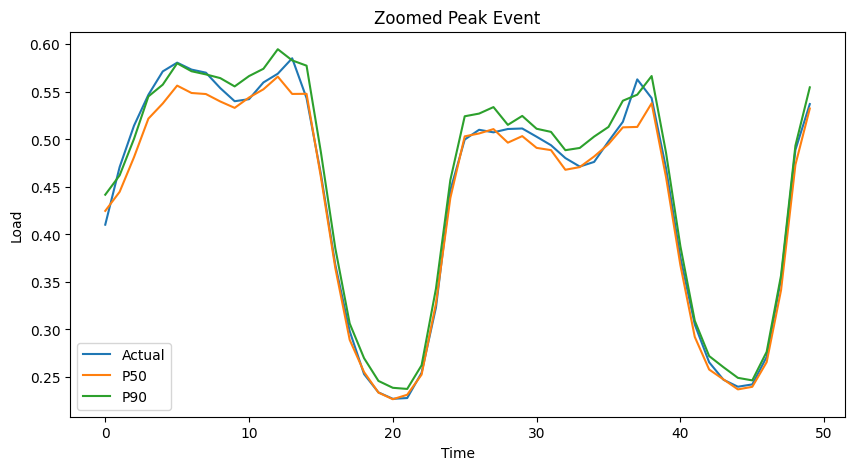

In [13]:
plt.figure(figsize=(10,5))

start = 50
end = 100

plt.plot(actual[start:end], label="Actual")
plt.plot(p50[start:end], label="P50")
plt.plot(p90[start:end], label="P90")

plt.legend()
plt.title("Zoomed Peak Event")
plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig("outputs/figures/rq4_zoomed_peaks.pdf")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Metric": ["MAE", "Bias", "Peak Capture Rate"],
    "P50 (Median)": [mae_p50, bias_p50, np.nan],
    "P90 (Upper Quantile)": [mae_p90, bias_p90, capture_rate]
})

results.to_csv("outputs/tables/rq4_peak_results_part2.csv", index=False)

results

NameError: name 'pd' is not defined